### Convert freqs to radial distances, and vice versa

In [15]:
import pandas as pd
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [3]:
def freq_to_n(fpe):
    """
    Calculate electron density [cm-3] from plasma frequency in MHz].
    """
    ne = (fpe/(8.98e-3)) ** 2 # for harmonic fpe = 0.5f
    return ne


def n_to_freq(ne):
    """
    Calculate plasma frequency [MHz] from electron density [cm-3].
    """
    fpe = 8.98e-3 * np.sqrt(ne)
    return fpe


def newkirk(r, fold=1):
    """
    Newkirk electron-density model.
    fold: is a multiplicative factor to change the density scaling.
    """
    model = fold * 4.2e4 * 10 ** (4.32 / r)
    return model


def height_to_freq(r):
    """
    Convert radial height (in Rsun) to plasma frequency (MHz)
    using the Newkirk density model.
    """
    ne = newkirk(r)
    fpe = n_to_freq(ne)
    return fpe


def invert_newkirk(ne):
    """
    Invert the Newkirk electron-density model to find the radial distance
    for a given electron density.
    """

    def equation(r):
        # Define the equation for which we need to find the root.
        # It returns the difference between the model's density and the given density.
        return newkirk(r) - ne

    # Initial guess for the radial distance can be set to a reasonable value.
    r_guess = 1.0

    # Use fsolve to find the root of the equation, which is the radial distance r
    # that makes the equation zero.
    r_solution, = fsolve(equation, r_guess)
    return r_solution

In [6]:
df = pd.read_csv('/home/mnedal/data/csv_files/SRB_heights/heights_newest_3MF.csv')
df.columns

Index(['Unnamed: 0', 'Time', '1 Leblanc', '2 Leblanc', '3 Leblanc',
       '4 Leblanc', '1 Mann', '2 Mann', '3 Mann', '4 Mann', '1 Saito',
       '2 Saito', '3 Saito', '4 Saito', '1 Allen', '2 Allen', '3 Allen',
       '4 Allen', '1 Newkirk', '2 Newkirk', '3 Newkirk', '4 Newkirk'],
      dtype='object')

In [12]:
time = df['Time'].values
r_list = df['1 Newkirk'].values
r_list

array([1.33738667, 1.33653199, 1.33842695, 1.34121251, 1.3431681 ,
       1.35022247, 1.35563948, 1.36017311, 1.36992595, 1.3775402 ,
       1.37987628, 1.38083596, 1.38088644, 1.38059093, 1.37990247,
       1.38106003, 1.38380136, 1.38504091, 1.38516403, 1.38620653,
       1.38610799, 1.38794402, 1.39081746, 1.39059469, 1.39101833,
       1.39259378, 1.39336688, 1.39374767, 1.39553457, 1.39646915])

In [13]:
freqs = height_to_freq(r_list)
freqs

array([75.85620363, 76.03681497, 75.63726058, 75.05575849, 74.65162028,
       73.22128613, 72.15143316, 71.27449452, 69.44301049, 68.06334685,
       67.64858476, 67.47933364, 67.47045001, 67.5224851 , 67.64395663,
       67.43991121, 66.96049452, 66.7454567 , 66.72415568, 66.54422158,
       66.56119691, 66.24600784, 65.75737529, 65.79505703, 65.72342768,
       65.45811446, 65.32853185, 65.26485193, 64.96732034, 64.81255002])

In [30]:
dflf = pd.read_csv('/home/mnedal/data/ccuddy/burst3/burst_3LF.csv')
dfmf = pd.read_csv('/home/mnedal/data/ccuddy/burst3/burst_3MF.csv')
dfuf = pd.read_csv('/home/mnedal/data/ccuddy/burst3/burst_3HF.csv')

freqslf = height_to_freq(dflf['1 Newkirk'].values)
freqsmf = height_to_freq(dfmf['1 Newkirk'].values)
freqsuf = height_to_freq(dfuf['1 Newkirk'].values)

dflh = pd.read_csv('/home/mnedal/data/ccuddy/burst3/burst_3LH.csv')
dfmh = pd.read_csv('/home/mnedal/data/ccuddy/burst3/burst_3MH.csv')
dfuh = pd.read_csv('/home/mnedal/data/ccuddy/burst3/burst_3HH.csv')

freqslh = height_to_freq(dflh['1 Newkirk'].values)
freqsmh = height_to_freq(dfmh['1 Newkirk'].values)
freqsuh = height_to_freq(dfuh['1 Newkirk'].values)

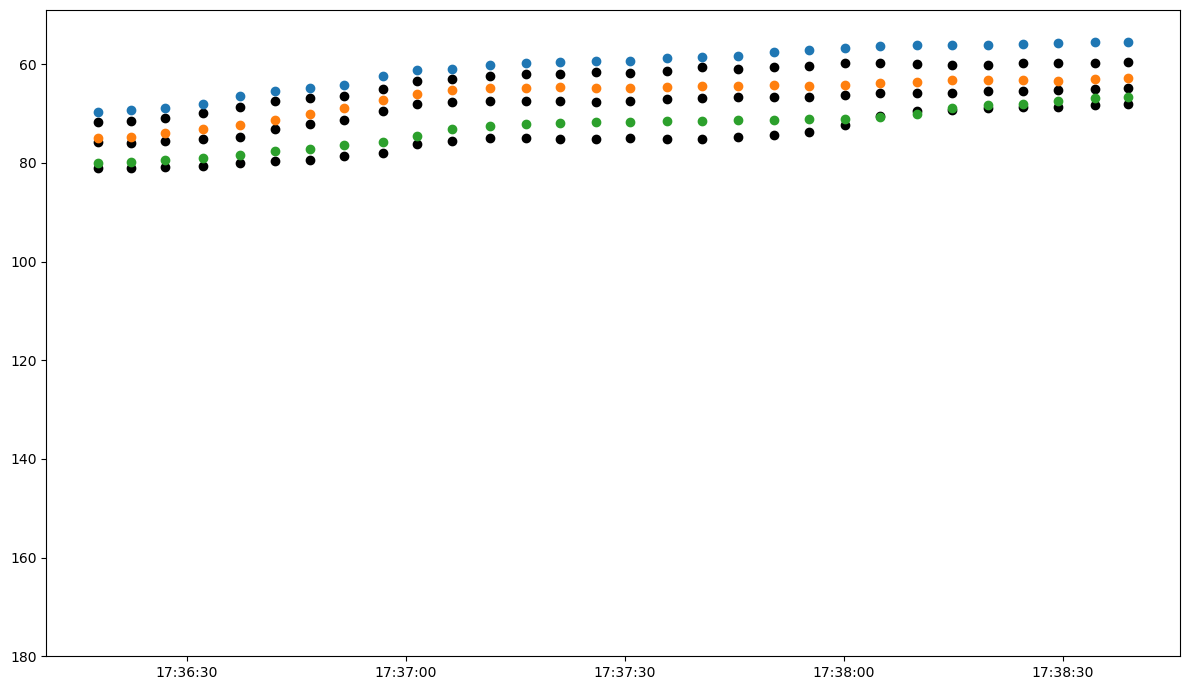

In [31]:
fig = plt.figure(figsize=[12,7])
ax = fig.add_subplot(111)

ax.scatter(time, freqslf, c='k')
ax.scatter(time, freqsmf, c='k')
ax.scatter(time, freqsuf, c='k')

ax.scatter(time, freqslh)
ax.scatter(time, freqsmh)
ax.scatter(time, freqsuh)

ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
# ax.set_ylim(ax.get_ylim()[::-1])
ax.set_ylim(180, 49)
fig.tight_layout()
plt.show()